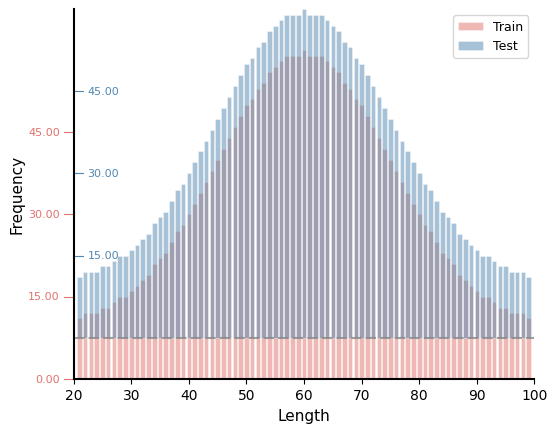

In [1]:
from plotcraft.draw import train_test_lift
import numpy as np
import matplotlib.pyplot as plt
train_data = np.arange(21, 100,dtype=int)
sigma, mu = 15, 60
y = np.exp(-(train_data - mu) ** 2 / (2 * sigma ** 2))
train_count = (y * 50 + 10).astype(int)

test_data = train_data.copy()
test_count = train_count.copy()

fig, ax = train_test_lift([train_data,train_count],[test_data,test_count],paired=False)
ax.set_xlabel('Length', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11, labelpad=35)
plt.show()

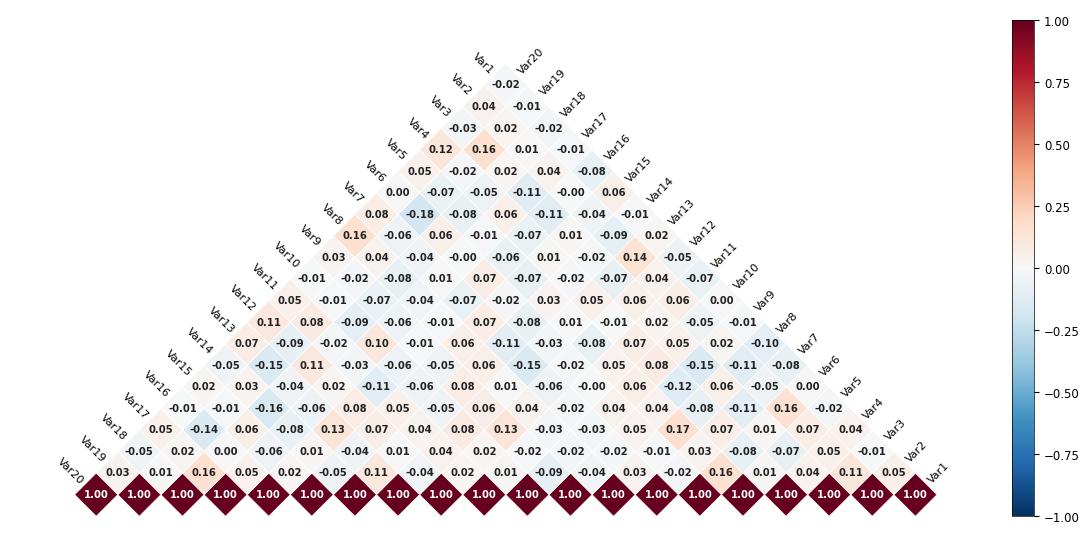

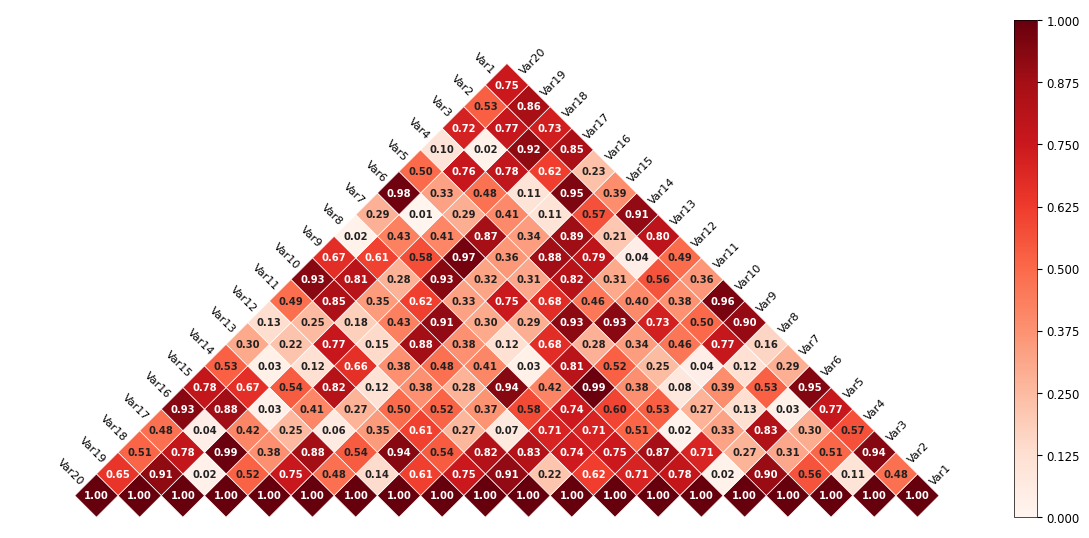

In [2]:
from plotcraft.draw import triangular_heatmap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
n_samples, n_vars = 200, 20
data = np.random.randn(n_samples, n_vars)
cols = [f"Var{i + 1}" for i in range(n_vars)]
df = pd.DataFrame(data, columns=cols)
n = n_vars
corr = np.ones((n, n))
pvalue = np.ones((n, n))
for i in range(n):
    for j in range(i + 1, n):
        r, p = stats.spearmanr(df.iloc[:, i], df.iloc[:, j])
        corr[i, j] = r
        corr[j, i] = r
        pvalue[i, j] = p
        pvalue[j, i] = p
corr_df = pd.DataFrame(corr, index=cols, columns=cols)
pvalue_df = pd.DataFrame(pvalue, index=cols, columns=cols)
fig, ax = triangular_heatmap(
    corr_df,
    annot=True,
    annot_kws={'size': 7.2},
    linewidths=0.5,
    linecolor='white',
    ticks_size=8,
    vmax=1,
    vmin=-1,
)
plt.show()
fig, ax = triangular_heatmap(
    pvalue_df,
    annot=True,
    annot_kws={'size': 7.2},
    linewidths=0.5,
    linecolor='white',
    ticks_size=8,
    vmax=1,
    vmin=0,
    cmap="Reds"
)
plt.show()

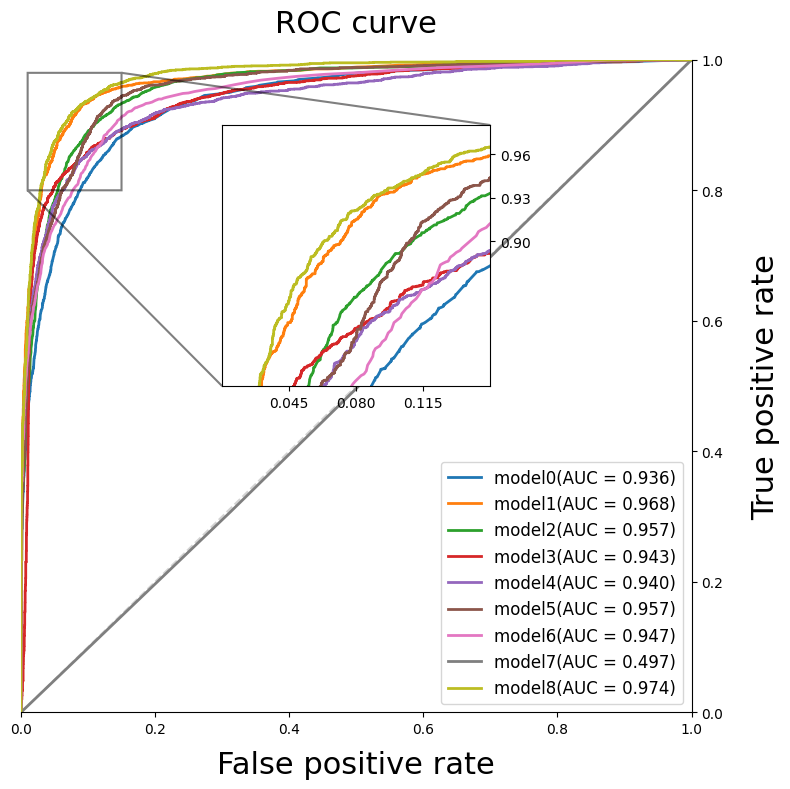

In [3]:
import numpy as np
from plotcraft.draw import enlarged_roc_curve
import matplotlib.pyplot as plt
array = np.load('./data/true_score.npy')
datas = [[array[i],array[i+1]] for i in range(0,array.shape[0],2)]
enlarged_roc_curve(*datas,labels=[f'model{i}' for i in range(len(datas))],enlarged=True,to_enlarge_frame_location=[0.01,0.80,0.15,0.98],enlarged_frame_location=[0.3, 0.5, 0.4, 0.4],enlarged_frame_xticks=[0.045, 0.08, 0.115],enlarged_frame_yticks=[0.9, 0.93, 0.96],enlarged_frame_transparent=False)
plt.show()

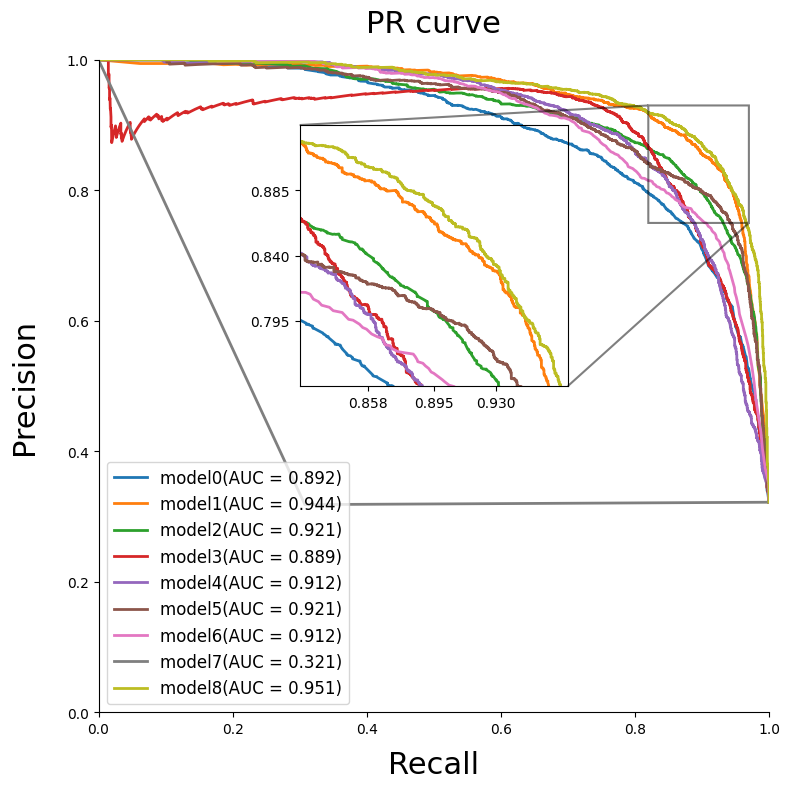

In [4]:
import numpy as np
from plotcraft.draw import enlarged_pr_curve
import matplotlib.pyplot as plt
array = np.load('./data/true_score.npy')
datas = [[array[i],array[i+1]] for i in range(0,array.shape[0],2)]
enlarged_pr_curve(*datas,labels=[f'model{i}' for i in range(len(datas))],enlarged=True,to_enlarge_frame_location=[0.82,0.75,0.97,0.93],enlarged_frame_location=[0.3, 0.5, 0.4, 0.4],enlarged_frame_xticks=[0.858,0.895,0.93],enlarged_frame_yticks=[0.795, 0.84, 0.885])
plt.show()

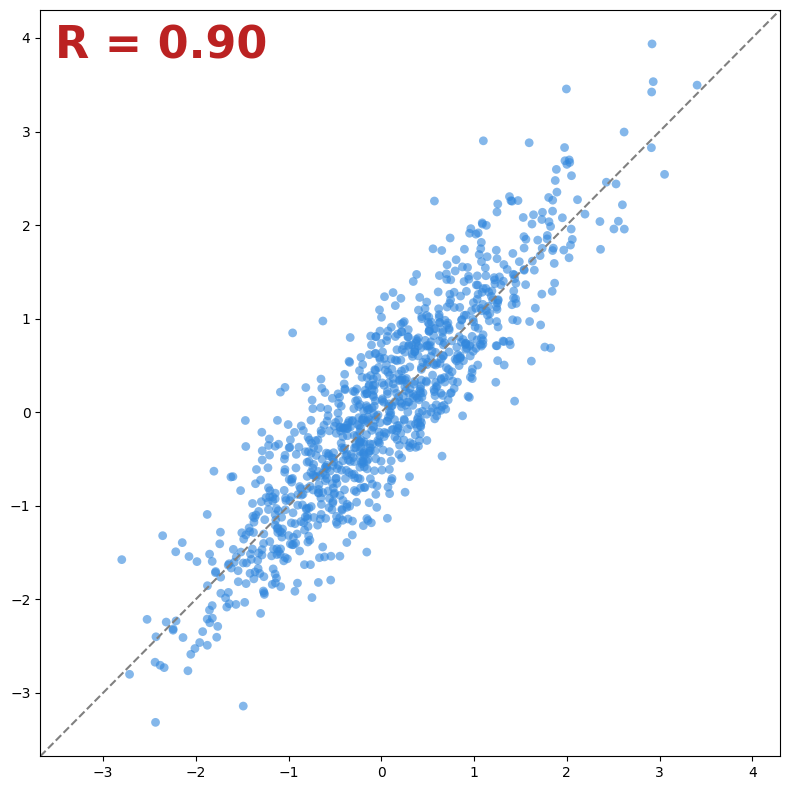

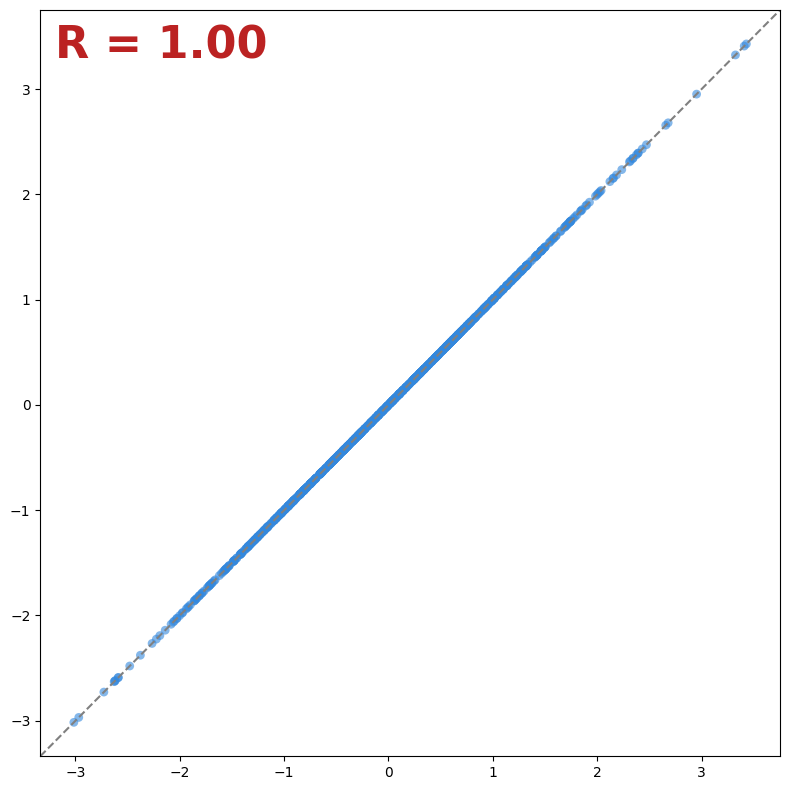

In [5]:
from plotcraft.draw import correlation_graph_between_prediction_and_reality
import numpy as np
import matplotlib.pyplot as plt
real = np.random.randn(1000)
pred = real + np.random.randn(1000) * 0.5
correlation_graph_between_prediction_and_reality(real, pred)
plt.show()

real = np.random.randn(1000)
pred = real.copy()
correlation_graph_between_prediction_and_reality(real, pred)
plt.show()

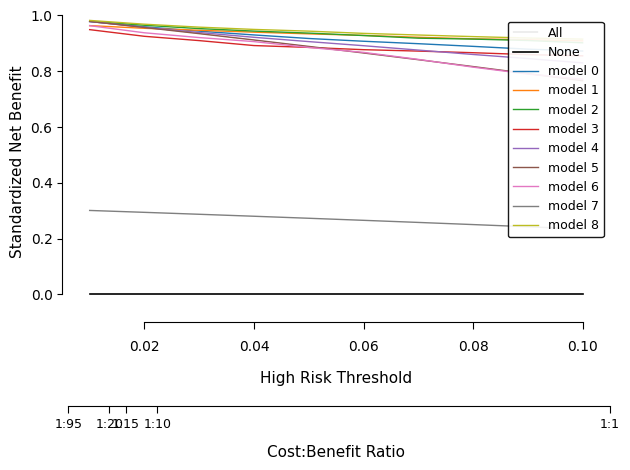

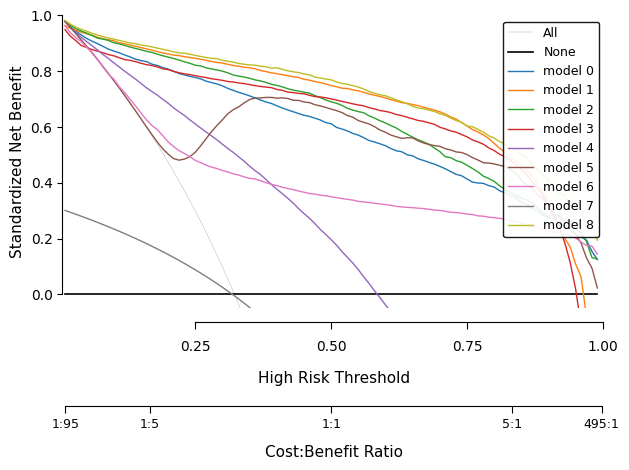

F:\AIlib\plotcraft\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


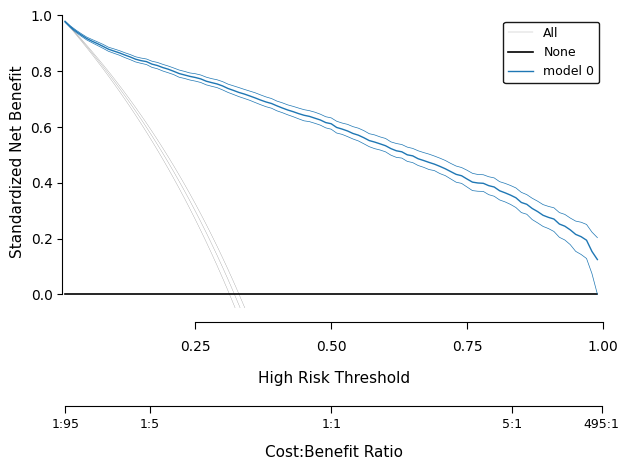

In [1]:
from plotcraft.draw import dca_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
array = np.load('./data/true_score.npy')
datas = [pd.DataFrame(np.array([array[i],array[i+1]]).T,columns=['true','pred']) for i in range(0,array.shape[0],2)]
dca_curve(*datas,dataframe_cols=['true','pred'],thresholds=np.arange(0.01, 0.11, 0.01))
plt.show()

dca_curve(*datas,dataframe_cols=['true','pred'],thresholds=np.arange(0.01, 1.01, 0.01))
plt.show()

dca_curve(datas[0], dataframe_cols=['true','pred'],thresholds=np.arange(0.01, 1.01, 0.01), confidence_intervals=0.95)
plt.show()